In [ ]:
# IMPORTS

import pandas as pd
import numpy as np

In [ ]:
# LOAD DATA SETS

try:
  # 2022-23 Data (Match by match logs)
  df_raw_22 = pd.read_csv('FPL_logs.csv', low_memory = False)

  # 2023-24 Data (European Season Summaries)
  df_raw_23 = pd.read_csv('cleaned_2023-24.csv')

  # 2024-25 Data (Premier League Season Summary)
  df_raw_24 = pd.read_csv('fbref_PL_2024-25.csv')

  print("All three data sets loaded successfully.")

except FileNotFoundError as e:
  print(f"Error loading files: {e}. Make sure all 3 CSVs are uploaded.")

All three data sets loaded successfully.


In [ ]:
# DATA CLEANING AND STANDARDIZATION

# 1. Clean 2022-23 Data
# Filter for 22-23 season
df_22 = df_raw_22[df_raw_22['Season'] == '2022-23'].copy()

# Aggregate match by match data into season totals
df_22_agg = df_22.groupby(['Name', 'Team']).agg({'Min': 'sum', 'Gls': 'sum', 'Ast': 'sum', 'Sh': 'sum', 'xG': 'sum', 'Pos': 'first'}).reset_index()

# Standardize columns
df_22_agg.rename(columns={'Name': 'Player', 'Team': 'Squad', 'Sh': 'Shots'}, inplace=True)

df_22_agg['Player'] = df_22_agg['Player'].str.replace('-', ' ')

df_22_agg['Season'] = '2022-2023'

top_10_22 = ['Manchester City', 'Arsenal', 'Manchester Utd', 'Newcastle Utd', 'Liverpool', 'Brighton', 'Aston Villa', 'Tottenham', 'Brentford', 'Fulham']

# Filter for strikers in top 10 teams
df_clean_22 = df_22_agg[(df_22_agg['Squad'].isin(top_10_22)) & (df_22_agg['Pos'].str.contains('FW|RW|LW', case=False, na=False)) & (df_22_agg['Min'] >= 900)].copy()


# 2. Clean 2023-24 Data
# Filter for Premier League
df_23 = df_raw_23[df_raw_23['comp'] == 'Premier League'].copy()

# Standardize columns
df_23.rename(columns={'player': 'Player', 'squad': 'Squad', 'Avg Mins per Match': 'Min', 'Goals': 'Gls', 'Assists': 'Ast', 'Expected Goals': 'xG', 'Total Shots': 'Shots', 'pos': 'Pos'}, inplace=True)
df_23['Season'] = '2023-2024'

top_10_23 = ['Manchester City', 'Arsenal', 'Liverpool', 'Aston Villa', 'Tottenham', 'Chelsea', 'Newcastle Utd', 'Manchester Utd', 'West Ham', 'Crystal Palace']

# Filter for strikers in top 10 teams
df_clean_23 = df_23[(df_23['Squad'].isin(top_10_23)) & (df_23['Pos'].str.contains('FW', case=False, na=False)) & (df_23['Min'] >= 900)].copy()


# 3. Clean 2024-25 Data
# Standardize columns
df_raw_24.columns = df_raw_24.columns.str.strip()
df_raw_24['Player'] = df_raw_24['Player'].str.strip()
df_raw_24['Squad'] = df_raw_24['Squad'].str.strip()
df_raw_24['Season'] = '2024-2025'

# This data set does not have "Shots", so I fill it with nan.
df_raw_24['Shots'] = np.nan

top_10_24 = ['Liverpool', 'Arsenal', 'Manchester City', 'Chelsea', 'Newcastle Utd', 'Aston Villa', "Nott'ham Forest", 'Brighton', 'Bournemouth', 'Brentford']

# Filter for strikers in top 10 teams
df_clean_24 = df_raw_24[(df_raw_24['Squad'].isin(top_10_24)) & (df_raw_24['Pos'].str.contains('FW', case=False, na=False)) & (df_raw_24['Min'] >= 900)].copy()

# Merging all seasons into one master data set
core_columns = ['Season', 'Player', 'Squad', 'Pos', 'Min', 'Gls', 'Ast', 'Shots', 'xG']
master_df = pd.concat([df_clean_22[core_columns], df_clean_23[core_columns], df_clean_24[core_columns]], ignore_index=True)

print(f"Master data set created. Total strikers analyzed across 3 seasons: {len(master_df)}")

Master data set created. Total strikers analyzed across 3 seasons: 138


In [ ]:
# BASIC STATISTICAL ANALYSIS

print("=== Top 10 Raw Goalscoring Seasons (2022-2025) ===")

# Sort the master dataframe by raw goals to see who dominated the league
top_scorers = master_df.sort_values(by='Gls', ascending=False).head(10)
display(top_scorers[['Season', 'Player', 'Squad', 'Min', 'Gls', 'Ast']])

print("\n=== Summary Statistics by Season ===")

# Show the average goals and minutes played by Top 10 team strikers each year
season_summary = master_df.groupby('Season').agg({'Player': 'count', 'Min': 'mean', 'Gls': 'mean', 'Ast': 'mean'}).rename(columns={'Player': 'Number of Qual. Strikers', 'Min': 'Avg Mins', 'Gls': 'Avg Goals'})

display(round(season_summary, 1))

=== Top 10 Raw Goalscoring Seasons (2022-2025) ===


,Season,Player,Squad,Min,Gls,Ast
16,2022-2023,Erling Haaland,Manchester City,2769.0,36.0,8.0
18,2022-2023,Harry Kane,Tottenham,3405.0,30.0,3.0
125,2024-2025,Mohamed Salah,Liverpool,3371.0,29.0,18.0
55,2023-2024,Erling Haaland,Manchester City,2552.0,27.0,5.0
101,2024-2025,Alexander Isak,Newcastle Utd,2756.0,23.0,6.0
98,2024-2025,Erling Haaland,Manchester City,2736.0,22.0,3.0
73,2023-2024,Cole Palmer,Chelsea,2607.0,22.0,11.0
58,2023-2024,Alexander Isak,Newcastle Utd,2255.0,21.0,2.0
20,2022-2023,Ivan Toney,Brentford,2951.0,20.0,4.0
110,2024-2025,Bryan Mbeumo,Brentford,3414.0,20.0,7.0



=== Summary Statistics by Season ===


,Number of Qual. Strikers,Avg Mins,Avg Goals,Ast
Season,,,,
2022-2023,41,1947.0,9.3,4.4
2023-2024,43,2052.3,9.7,5.0
2024-2025,54,2133.5,7.9,4.7


In [ ]:
# NORMALIZED AND EFFICIENCY METRICS

# 1. Calculate Per 90 Metrics for fair comparison
master_df['Gls_per_90'] = round((master_df['Gls'] / master_df['Min']) * 90, 2)
master_df['Ast_per_90'] = round((master_df['Ast'] / master_df['Min']) * 90, 2)
master_df['xG_per_90'] = round((master_df['xG'] / master_df['Min']) * 90, 2)

# 2. Calculate Efficiency (Finishing Efficiency = Goals / Expected Goals (xG). > 1.0 means ruthless finishing.)
master_df['Finishing_Efficiency'] = round(master_df['Gls'] / (master_df['xG'] + 1e-9), 2)

# 3. Calculate Conversion Rate (Goals / Shots (Not applicable for the 24-25 season because of lack of data))
master_df['Conversion_Rate_%'] = round((master_df['Gls'] / (master_df['Shots'] + 1e-9)) * 100, 2)

# 4. View the Most Clinical Finishers Across the 3 Years
# Filter for players who scored at least 5 goals to avoid anomalies
clinical_finishers = master_df[master_df['Gls'] >= 5].sort_values(by='Finishing_Efficiency', ascending=False)

view_cols = ['Season', 'Player', 'Squad', 'Gls', 'xG', 'Gls_per_90', 'Finishing_Efficiency']

print("=== Top 10 Most Clinical Strikers (Finishing Efficiency) ===")
display(clinical_finishers[view_cols].head(10))

print("\n=== Worst 5 Underperformers (Scored less than their xG) ===")
display(clinical_finishers[view_cols].tail(5))

=== Top 10 Most Clinical Strikers (Finishing Efficiency) ===


,Season,Player,Squad,Gls,xG,Gls_per_90,Finishing_Efficiency
37,2022-2023,Roberto Firmino,Liverpool,11.0,5.4,0.82,2.04
100,2024-2025,Callum Hudson-Odoi,Nott'ham Forest,5.0,2.5,0.21,2.00
65,2023-2024,Noni Madueke,Chelsea,5.0,2.5,0.43,2.00
62,2023-2024,Diogo Jota,Liverpool,10.0,5.3,0.79,1.89
34,2022-2023,Phil Foden,Manchester City,11.0,5.9,0.54,1.86
50,2023-2024,Phil Foden,Manchester City,19.0,10.3,0.60,1.84
72,2023-2024,Michael Olise,Crystal Palace,10.0,5.5,0.71,1.82
64,2023-2024,Dejan Kulusevski,Tottenham,8.0,4.7,0.26,1.70
110,2024-2025,Bryan Mbeumo,Brentford,20.0,12.3,0.53,1.63
63,2023-2024,Mohammed Kudus,West Ham,8.0,5.1,0.29,1.57



=== Worst 5 Underperformers (Scored less than their xG) ===


,Season,Player,Squad,Gls,xG,Gls_per_90,Finishing_Efficiency
107,2024-2025,Noni Madueke,Chelsea,7.0,9.6,0.31,0.73
71,2023-2024,Darwin Núñez,Liverpool,11.0,16.3,0.48,0.67
47,2023-2024,Luis Díaz,Liverpool,8.0,11.9,0.27,0.67
11,2022-2023,Danny Welbeck,Brighton,6.0,9.4,0.29,0.64
61,2023-2024,Brennan Johnson,Tottenham,5.0,10.3,0.22,0.49


In [ ]:
# TREND ANALYSIS

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set a visual theme for the charts for clearer visuals
sns.set_theme(style="whitegrid", palette="muted")
print("Visualization libraries successfully imported.")

Visualization libraries successfully imported.


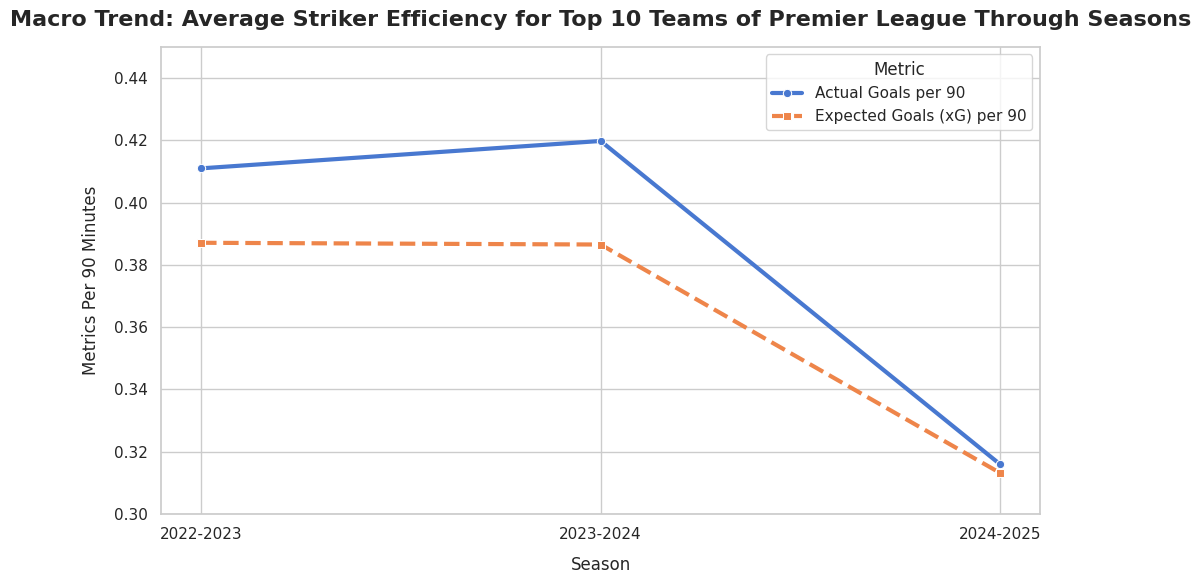

In [ ]:
# League-Wide Macro Striker Trends

# Calculate average goals per 90 and xG per 90 for each season
season_trends = master_df.groupby('Season')[['Gls_per_90', 'xG_per_90']].mean().reset_index()

# Set up matplotlib
fig, ax = plt.subplots(figsize=(10, 6))

# Plot both metrics as lines on the same graph
sns.lineplot(data=season_trends, x='Season', y='Gls_per_90', marker='o', linewidth=3, label='Actual Goals per 90', ax=ax)
sns.lineplot(data=season_trends, x='Season', y='xG_per_90', marker='s', linewidth=3, linestyle='--', label='Expected Goals (xG) per 90', ax=ax)

# Format the graph to make it readable
ax.set_title('Macro Trend: Average Striker Efficiency for Top 10 Teams of Premier League Through Seasons', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Season', fontsize=12, labelpad=10)
ax.set_ylabel('Metrics Per 90 Minutes', fontsize=12, labelpad=10)
ax.set_ylim(0.3, 0.45)
plt.legend(title='Metric', fontsize=11)

plt.tight_layout()

plt.show()

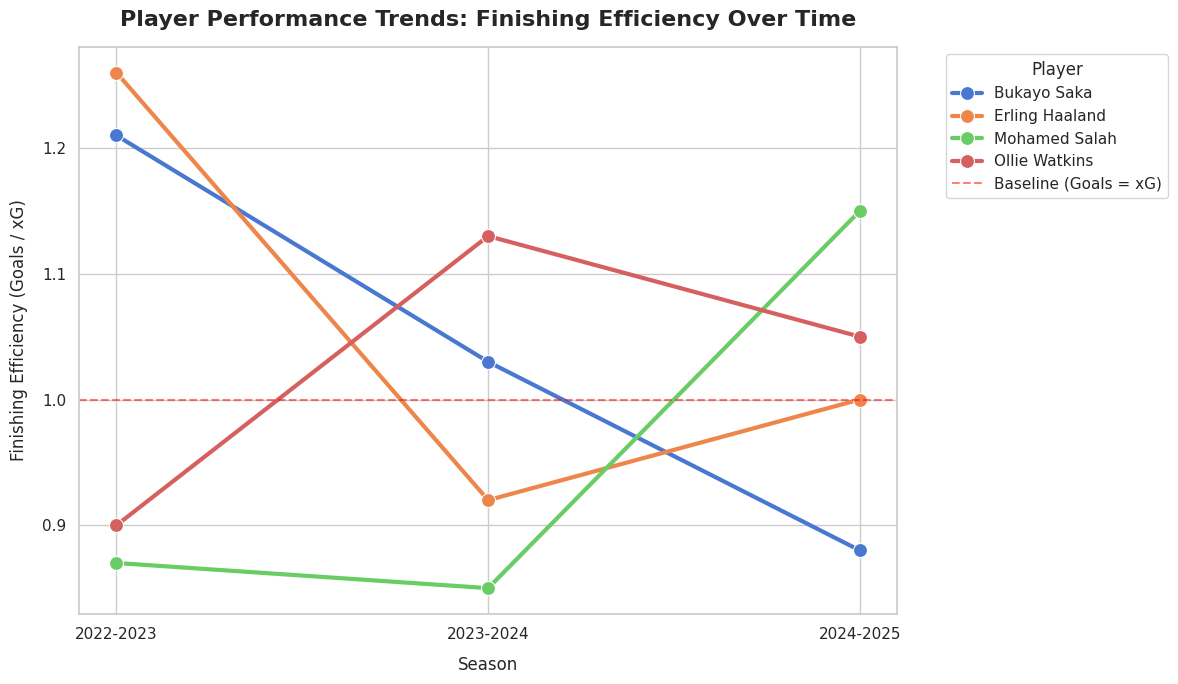

In [ ]:
# Individual Micro Striker Trends

# Identify a few players who have data across multiple seasons
# Could be changed to look into different players
target_players = ['Erling Haaland', 'Ollie Watkins', 'Bukayo Saka', 'Mohamed Salah']

# Filter the master data set for only these players
player_trends = master_df[master_df['Player'].isin(target_players)].copy()

# Set up matplotlib
fig, ax = plt.subplots(figsize=(12, 7))

# Plot a line graph that also colors the lines by player
sns.lineplot(data=player_trends, x='Season', y='Finishing_Efficiency', hue='Player', marker='o', markersize=10, linewidth=3, ax=ax)

# Add a line at 1.0 to reference baseline
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Baseline (Goals = xG)')

# Format the graph to make it readable
ax.set_title('Player Performance Trends: Finishing Efficiency Over Time', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Season', fontsize=12, labelpad=10)
ax.set_ylabel('Finishing Efficiency (Goals / xG)', fontsize=12, labelpad=10)

# Move the legend outside the graph so it does not overlap data lines
plt.legend(title='Player', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

In [ ]:
# MACHINE LEARNING SETUP AND DATA SPLITTING

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features (independent variables) and target(dependent variable)
features = ['xG_per_90', 'Ast_per_90', 'Min']
target = 'Gls_per_90'

# Temporal data split to train on the past and test on the present data
train_data = master_df[master_df['Season'].isin(['2022-2023', '2023-2024'])].copy()
test_data = master_df[master_df['Season'] == '2024-2025'].copy()

# Seperate the features and the target for both sets
X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

print(f"Training model on {len(X_train)} historical striker seasons...")
print(f"Testing model on {len(X_test)} current striker seasons...")

Training model on 84 historical striker seasons...
Testing model on 54 current striker seasons...


In [ ]:
# Model Training and Evaluation

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the unseen 24-25 data
y_pred = model.predict(X_test)

# Evaluate model accuracy
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Predictive Model Evaluation ===")
print(f"R-Squared (R²): {r2:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f} goals per 90")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.3f} goals per 90\n")

# Display the weight the model assigned to each feature
print("=== Feature Importance ===")
for feature, coef in zip(features, model.coef_):
  print(f"{feature}: {coef:.4f}")

=== Predictive Model Evaluation ===
R-Squared (R²): 0.739
Mean Absolute Error (MAE): 0.079 goals per 90
Root Mean Squared Error (RMSE): 0.097 goals per 90

=== Feature Importance ===
xG_per_90: 0.9093
Ast_per_90: -0.0855
Min: 0.0000


In [ ]:
# Prediction Results Table

test_data['Predicted_Gls_per_90'] = np.round(y_pred, 2)

test_data['Prediction_Error'] = test_data['Gls_per_90'] - test_data['Predicted_Gls_per_90']

results_view = test_data[['Player', 'Squad', 'xG_per_90', 'Predicted_Gls_per_90', 'Gls_per_90', 'Prediction_Error']]

results_view = results_view.sort_values(by='Prediction_Error', ascending=False)

print("=== 2024-2025 Striker Predictions vs. Reality ===")
display(results_view)

=== 2024-2025 Striker Predictions vs. Reality ===


,Player,Squad,xG_per_90,Predicted_Gls_per_90,Gls_per_90,Prediction_Error
110,Bryan Mbeumo,Brentford,0.32,0.36,0.53,0.17
137,Chris Wood,Nott'ham Forest,0.41,0.45,0.61,0.16
125,Mohamed Salah,Liverpool,0.67,0.65,0.77,0.12
96,Cody Gakpo,Liverpool,0.33,0.37,0.47,0.10
108,Omar Marmoush,Manchester City,0.42,0.46,0.54,0.08
101,Alexander Isak,Newcastle Utd,0.66,0.67,0.75,0.08
115,Jacob Murphy,Newcastle Utd,0.22,0.24,0.31,0.07
86,Harvey Barnes,Newcastle Utd,0.37,0.40,0.46,0.06
128,Kevin Schade,Brentford,0.32,0.37,0.43,0.06
91,Jeremy Doku,Manchester City,0.08,0.12,0.18,0.06


In [ ]:
# CREATING THE CUSTOM PERFORMANCE INDEX (CPI)

from sklearn.preprocessing import MinMaxScaler

# Filter for the most recent season (24-25) to evaluate current strikers
current_strikers = master_df[master_df['Season'] == '2024-2025'].copy()

# Select the metrics that will make up the index
index_metrics = ['Gls_per_90', 'xG_per_90', 'Finishing_Efficiency', 'Ast_per_90']

# Initialize the Scaler (converts all stats to a 0-100 scale based on the highest/lowest in the league)
scaler = MinMaxScaler(feature_range=(0, 100))

# Create normalized columns
for metric in index_metrics:
  current_strikers[f'{metric}_Score'] = scaler.fit_transform(current_strikers[[metric]])

# Define custom weights
weights = {'Gls_per_90_Score': 0.40, 'xG_per_90_Score': 0.25, 'Finishing_Efficiency_Score': 0.20, 'Ast_per_90_Score': 0.15}

# Calculate the final Custom Performance Index (CPI)
current_strikers['CPI'] = ((current_strikers['Gls_per_90_Score'] * weights['Gls_per_90_Score']) +
                           (current_strikers['xG_per_90_Score'] * weights['xG_per_90_Score']) +
                           (current_strikers['Finishing_Efficiency_Score'] * weights['Finishing_Efficiency_Score']) +
                           (current_strikers['Ast_per_90_Score'] * weights['Ast_per_90_Score']))

# Round the index for clean viewing
current_strikers['CPI'] = round(current_strikers['CPI'], 1)

In [ ]:
# Traditional vs. Custom Index Comparison

# Create a traditional rank (based on raw goals)
current_strikers['Rank_Traditional'] = current_strikers['Gls'].rank(ascending=False, method='min')

# Create the custom rank (based on new CPI)
current_strikers['Rank_CPI'] = current_strikers['CPI'].rank(ascending=False, method='min')

# Calculate difference in ranks (positive means the index favors the player more than traditional stats)
current_strikers['Rank_Difference'] = current_strikers['Rank_Traditional'] - current_strikers['Rank_CPI']

# Select columns to display in the final report
final_columns = ['Player', 'Squad', 'Gls', 'Rank_Traditional', 'CPI', 'Rank_CPI', 'Rank_Difference']

# Sort by the new custom index
cpi_rankings = current_strikers[final_columns].sort_values(by='CPI', ascending=False)

print("=== Top 15 Complete Strikers (Custom CPI Rankings) ===")
display(cpi_rankings.head(15))

print("\n=== Biggest 'Hidden Gems' (Players rated higher by CPI than by raw goals) ===")
hidden_gems = cpi_rankings.sort_values(by='Rank_Difference', ascending=False).head(5)
display(hidden_gems)

=== Top 15 Complete Strikers (Custom CPI Rankings) ===


,Player,Squad,Gls,Rank_Traditional,CPI,Rank_CPI,Rank_Difference
125,Mohamed Salah,Liverpool,29.0,1.0,86.9,1.0,0.0
101,Alexander Isak,Newcastle Utd,23.0,2.0,77.2,2.0,0.0
98,Erling Haaland,Manchester City,22.0,3.0,73.9,3.0,0.0
133,Ollie Watkins,Aston Villa,16.0,7.0,63.4,4.0,3.0
136,Yoane Wissa,Brentford,19.0,6.0,62.3,5.0,1.0
137,Chris Wood,Nott'ham Forest,20.0,4.0,60.3,6.0,-2.0
105,Diogo Jota,Liverpool,6.0,29.0,56.6,7.0,22.0
110,Bryan Mbeumo,Brentford,20.0,4.0,56.5,8.0,-4.0
90,Luis Díaz,Liverpool,13.0,9.0,54.9,9.0,0.0
103,João Pedro,Brighton,10.0,12.0,54.7,10.0,2.0



=== Biggest 'Hidden Gems' (Players rated higher by CPI than by raw goals) ===


,Player,Squad,Gls,Rank_Traditional,CPI,Rank_CPI,Rank_Difference
105,Diogo Jota,Liverpool,6.0,29.0,56.6,7.0,22.0
117,Christopher Nkunku,Chelsea,3.0,41.0,41.6,24.0,17.0
118,Darwin Núñez,Liverpool,5.0,34.0,47.8,19.0,15.0
91,Jeremy Doku,Manchester City,3.0,41.0,40.1,27.0,14.0
108,Omar Marmoush,Manchester City,7.0,24.0,52.5,11.0,13.0
